<a href="https://colab.research.google.com/github/HyunseoHYU/Self_Study_California_Housing_Price_Analysis/blob/main/California_Housing_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# California Housing Data Analysis

Self-study by reading Hands on Machine Learning 3rd Ed.

# Project Overview

[0] Define<br><br>

[1] Collect House Data

 X = ['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity']

 y = ["median_house_value"]

 (income_cat은 층화추출 전용 컬럼이므로 분할 후 X에서 제거) <br><br>

[2] Data Split (Stratified Sampling) <br><br>

[3] EDA

 A. Correlation

 B. Derived Variable<br><br>

[4] Missing Value

 0. Divide Input Data and Label / Check NA

 A. drop rows

 B. drop columns

 C. Imputation (1. Check NA , 2. Decide Strategy, 3. SimpleImputer / fillna)<br><br>

[5] Drop Outliers (Pipeline 밖 : 행 삭제, train에만 적용)<br><br>

[6] Categorical Variable<br><br>

[7] Pipeline (ColumnTransformer)

 num : SimpleImputer -> Adder(파생변수) -> StandardScaler

 cat : OneHotEncoder<br><br>

# Pipeline 구분 기준

- Pipeline 안  : train으로 fit하고 train/test에 동일하게 transform해야 하는 것
                 (SimpleImputer, Adder, StandardScaler, OneHotEncoder)
- Pipeline 밖  : 분할, EDA, 비교용 데모, 행을 삭제하는 작업(이상치 제거)

In [1]:
#@title 변수 이름 정리 (Variable Index)

"""
[0] Define
- RANDOM_STATE          : 난수 시드 (재현성)
- TEST_SIZE             : 테스트셋 비율
- TRAIN_SIZE            : 학습셋 비율 (미사용)
- FIGSIZE               : 그래프 기본 크기

[1] Collect House Data
- DOWNLOAD_ROOT, HOUSING_PATH, HOUSING_URL : 데이터 다운로드 경로
- housing_raw           : 원본 데이터 전체 (20640 rows), [2]에서 income_cat 컬럼이 추가됨
- IMAGES_PATH           : 그림 저장 폴더

[2] Data Split (Stratified Sampling)
- income_cat            : median_income 구간화 컬럼 (housing_raw의 컬럼, 층화추출 기준)
- X_demo, y_demo, sss, demo_train_index, demo_test_index : (데모용) StratifiedShuffleSplit 예시
- train_set, test_set   : (데모용, 미사용) train_test_split 결과
- split, train_index, test_index : 실제 층화추출 splitter와 인덱스
- strat_train_set       : 층화추출 학습셋 (실제 학습 데이터의 원천)
- strat_test_set        : 층화추출 테스트셋 (최종 평가 전까지 학습 파이프라인에 사용 금지)

[3] EDA
- housing_train         : strat_train_set.copy() (EDA 대상, 파생변수는 추가하지 않음)
- housing_renamed       : 지도 시각화용 컬럼명 변경 복사본
- filename, california_img, axis : 캘리포니아 지도 이미지 오버레이용
- corr_matrix           : housing_train의 상관계수 행렬
- attributes            : scatter_matrix에 사용할 컬럼 리스트
- housing_eda           : housing_train 복사본 + 파생변수 (EDA 전용, 학습에는 사용 안 함)
- corr_matrix_eda       : housing_eda의 상관계수 행렬
- rooms_per_household, bedrooms_per_room, population_per_household : 파생변수 (housing_eda 컬럼)

[4] Missing Value
- X_train               : strat_train_set에서 label, income_cat을 뺀 입력 데이터
- y_train               : median_house_value (예측 타겟)
- null_rows_idx         : 결측치가 있는 행의 boolean mask
- housing_option1/2/3   : (비교용) dropna / drop column / median fillna
- median                : total_bedrooms 중앙값
- imputer               : SimpleImputer(strategy="median")
- housing_num           : X_train의 숫자형 컬럼
- num_attribs           : 숫자형 컬럼명 리스트 (Adder 인덱스, ColumnTransformer에서 사용)
- housing_num_imputed   : imputer.transform(housing_num) 결과 (numpy array)
- housing_tr            : housing_num_imputed를 DataFrame으로 복원한 것

[5] Drop Outliers
- outlier_detector      : SimpleImputer + IsolationForest 탐지용 Pipeline
- outlier_pred          : 이상치 예측 결과 (1=정상, -1=이상치)
- outliers              : 이상치 행 확인용
- keep_mask             : 정상 행 boolean mask (X, y에 동일하게 적용)
- X_train_clean, y_train_clean : 이상치 제거 후 입력 데이터 / 타겟

[6] Categorical Variable
- housing_cat           : X_train_clean의 ocean_proximity 컬럼
- ordinal_encoder       : OrdinalEncoder 인스턴스 (데모, 실제 사용 X)
- housing_cat_encoded   : 인코딩 결과 (numpy array)
- cat_encoder           : OneHotEncoder 인스턴스 (데모)

[7] Pipeline
- cat_attribs           : 범주형 컬럼명 리스트
- num_pipeline          : SimpleImputer -> Adder -> StandardScaler
- preprocessing         : ColumnTransformer (num_pipeline + OneHotEncoder)
- housing_prepared      : train 전처리 결과
- X_test, y_test        : strat_test_set의 입력 / 타겟
- X_test_prepared       : test 전처리 결과 (transform만 수행)
"""

'\n[0] Define\n- RANDOM_STATE          : 난수 시드 (재현성)\n- TEST_SIZE             : 테스트셋 비율\n- TRAIN_SIZE            : 학습셋 비율 (미사용)\n- FIGSIZE               : 그래프 기본 크기\n\n[1] Collect House Data\n- DOWNLOAD_ROOT, HOUSING_PATH, HOUSING_URL : 데이터 다운로드 경로\n- housing_raw           : 원본 데이터 전체 (20640 rows), [2]에서 income_cat 컬럼이 추가됨\n- IMAGES_PATH           : 그림 저장 폴더\n\n[2] Data Split (Stratified Sampling)\n- income_cat            : median_income 구간화 컬럼 (housing_raw의 컬럼, 층화추출 기준)\n- X_demo, y_demo, sss, demo_train_index, demo_test_index : (데모용) StratifiedShuffleSplit 예시\n- train_set, test_set   : (데모용, 미사용) train_test_split 결과\n- split, train_index, test_index : 실제 층화추출 splitter와 인덱스\n- strat_train_set       : 층화추출 학습셋 (실제 학습 데이터의 원천)\n- strat_test_set        : 층화추출 테스트셋 (최종 평가 전까지 학습 파이프라인에 사용 금지)\n\n[3] EDA\n- housing_train         : strat_train_set.copy() (EDA 대상, 파생변수는 추가하지 않음)\n- housing_renamed       : 지도 시각화용 컬럼명 변경 복사본\n- filename, california_img, axis : 캘리포니아 지도 이미지 오버레이용\n- corr_matri

## [0] Define

In [2]:
#@title [0] Define

RANDOM_STATE = 20260920
TEST_SIZE = 0.2
TRAIN_SIZE = 0.8
FIGSIZE = (10,5)

INPUT = ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity']
LABEL = "median_house_value"

## [1] Collect House Data

/tmp/ipykernel_1520/590840234.py:21: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  housing_tgz.extractall(path=housing_path)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


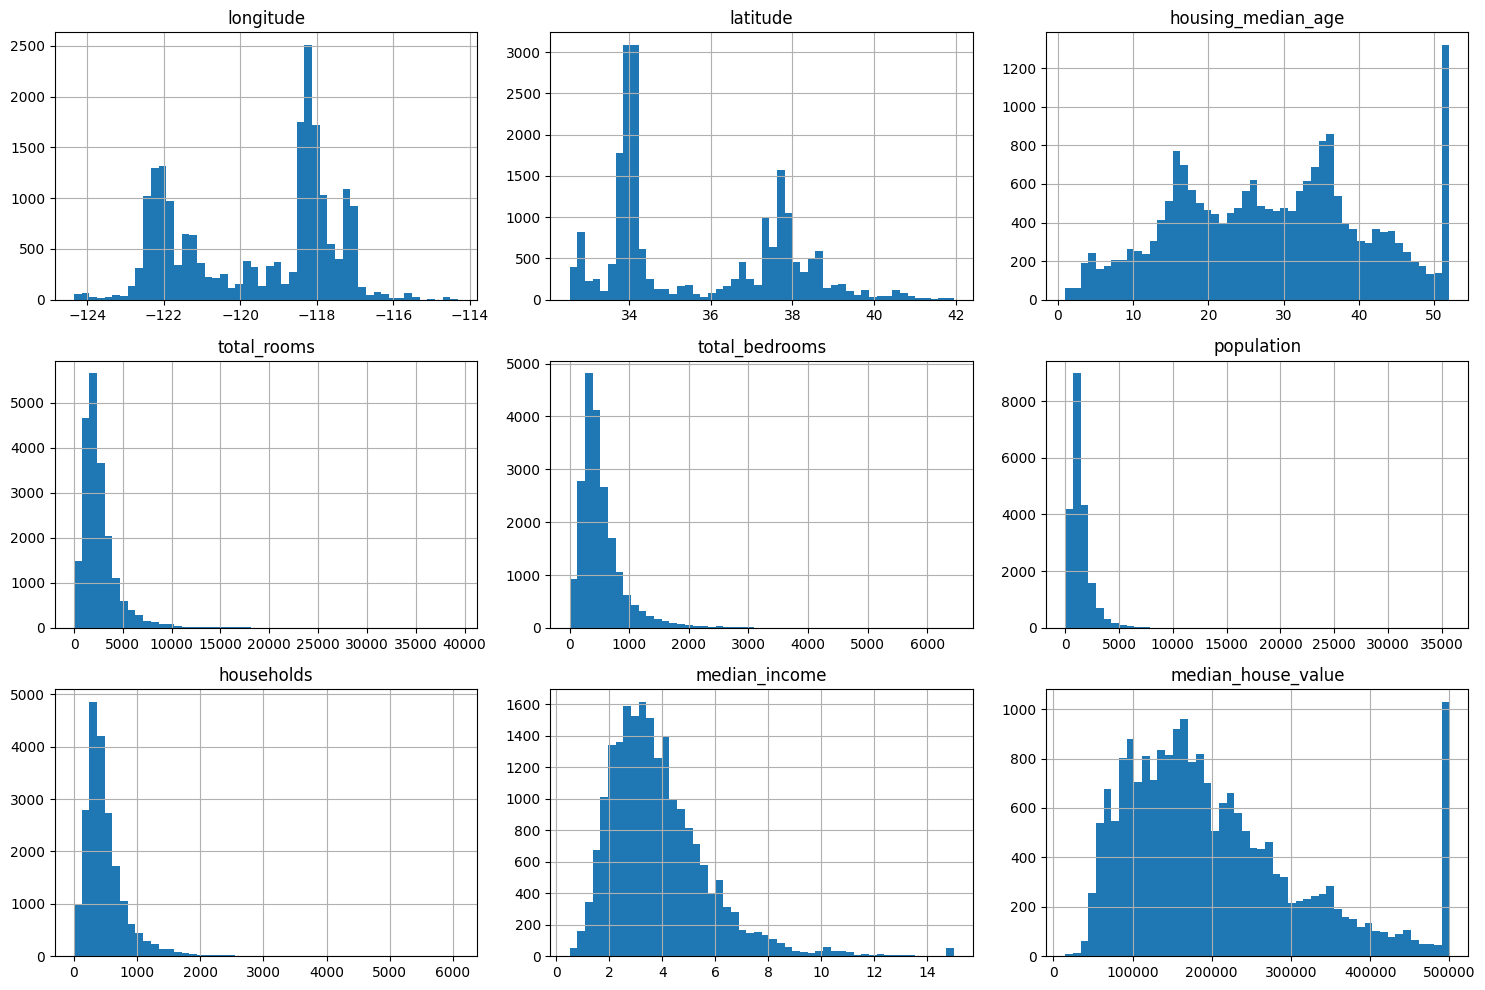

In [3]:
#@title [1] Collect House Data

import os
import tarfile
import urllib.request
import pandas as pd

DOWNLOAD_ROOT = "https://raw.githubusercontent.com/ageron/handson-ml2/master/"
HOUSING_PATH = os.path.join("datasets","housing")
HOUSING_URL = DOWNLOAD_ROOT + "datasets/housing/housing.tgz"

def fetch_housing_data(housing_url = HOUSING_URL, housing_path = HOUSING_PATH):
  csv_path = os.path.join(housing_path, "housing.csv")
  if os.path.exists(csv_path):
    print("THE FILE ALREADY EXISTS")
    return
  os.makedirs(housing_path, exist_ok = True)
  tgz_path = os.path.join(housing_path, "housing.tgz")
  urllib.request.urlretrieve(housing_url, tgz_path)
  with tarfile.open(tgz_path) as housing_tgz:
    housing_tgz.extractall(path=housing_path)

def load_housing_data(housing_path = HOUSING_PATH):
  csv_path = os.path.join(housing_path, "housing.csv")
  return pd.read_csv(csv_path)

fetch_housing_data()
housing_raw = load_housing_data()
housing_raw.head()

# check Null data and data types by columns
# info function always print output
housing_raw.info()

housing_raw.columns

# since <ocean_proximity> is a cateogorical variable, we need to look over the variables
housing_raw["ocean_proximity"].value_counts()

housing_raw.describe()

#Save the figures as PNG file

from pathlib import Path

IMAGES_PATH = Path() / "images" / "Figures"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout = True,
             fig_extension = "png", resolution = 300):
  path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
  if tight_layout:
    plt.tight_layout()
  plt.savefig(path, format=fig_extension, dpi = resolution)

import matplotlib.pyplot as plt

housing_raw.hist(bins=50, figsize=(15,10))
save_fig("housing_hist")
plt.show()

## [2] Data Split (Stratified Sampling)

StratifiedShuffleSplit(n_splits=5, random_state=20260920, test_size=0.5,
            train_size=None)
Fold 0
 Train: index = [3 0 2]
 Test:  index = [4 5 1]
Fold 1
 Train: index = [3 2 5]
 Test:  index = [0 1 4]
Fold 2
 Train: index = [4 0 2]
 Test:  index = [1 5 3]
Fold 3
 Train: index = [1 4 2]
 Test:  index = [5 3 0]
Fold 4
 Train: index = [0 2 3]
 Test:  index = [5 1 4]


<Axes: >

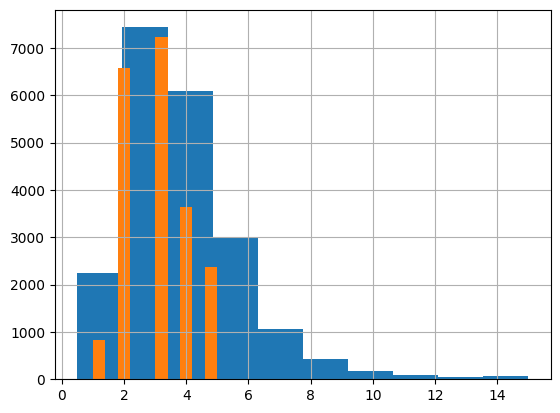

In [4]:
#@title [2] Create income_cat

import numpy as np
housing_raw["income_cat"] = pd.cut(housing_raw["median_income"],
                                   bins = [0,1.5,3.0,4.5,6.,np.inf],
                                   labels=[1,2,3,4,5])

# Example for Stratified Sampling
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit
X_demo = np.array([[1,2],
              [3,4],
              [1,2],
              [3,4],
              [1,2],
              [3,4]])
y_demo = np.array([0,0,0,1,1,1])
sss = StratifiedShuffleSplit(n_splits=5,test_size=0.5,random_state=RANDOM_STATE)
sss.get_n_splits(X_demo,y_demo)
print(sss)
for i, (demo_train_index, demo_test_index) in enumerate(sss.split(X_demo,y_demo)):
  print(f"Fold {i}")
  print(f" Train: index = {demo_train_index}")
  print(f" Test:  index = {demo_test_index}")

from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(housing_raw, test_size=TEST_SIZE, random_state = RANDOM_STATE, stratify=housing_raw["income_cat"])

housing_raw["median_income"].hist()

housing_raw["income_cat"].value_counts()

housing_raw["income_cat"].hist()

In [5]:
#@title [2] Stratified Shuffle Split

from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
for train_index, test_index in split.split(housing_raw, housing_raw["income_cat"]):
  strat_train_set = housing_raw.loc[train_index]
  strat_test_set = housing_raw.loc[test_index]

print(strat_test_set["income_cat"].value_counts() / len(strat_test_set))
print(housing_raw["income_cat"].value_counts()/len(housing_raw["income_cat"]))

income_cat
3    0.350533
2    0.318798
4    0.176357
5    0.114341
1    0.039971
Name: count, dtype: float64
income_cat
3    0.350581
2    0.318847
4    0.176308
5    0.114438
1    0.039826
Name: count, dtype: float64


## [3] EDA

<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 15678 to 4687
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   longitude           16512 non-null  float64 
 1   latitude            16512 non-null  float64 
 2   housing_median_age  16512 non-null  float64 
 3   total_rooms         16512 non-null  float64 
 4   total_bedrooms      16354 non-null  float64 
 5   population          16512 non-null  float64 
 6   households          16512 non-null  float64 
 7   median_income       16512 non-null  float64 
 8   median_house_value  16512 non-null  float64 
 9   ocean_proximity     16512 non-null  object  
 10  income_cat          16512 non-null  category
dtypes: category(1), float64(9), object(1)
memory usage: 1.4+ MB


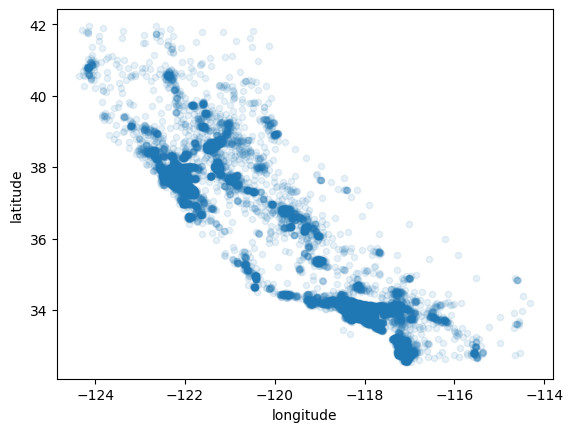

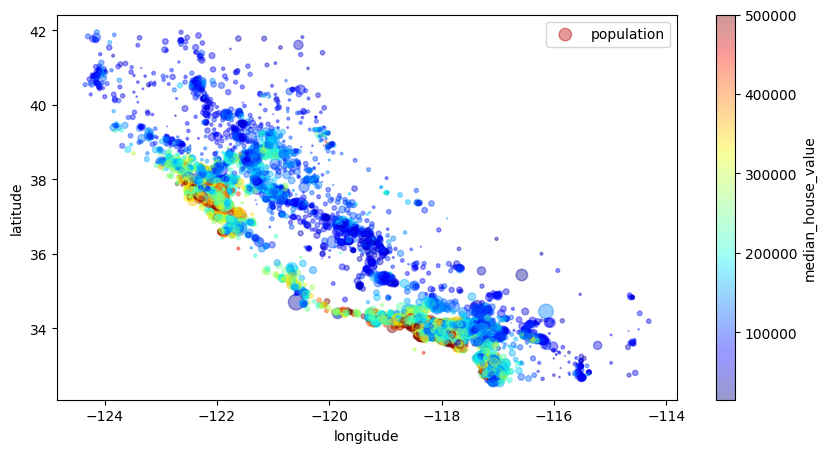

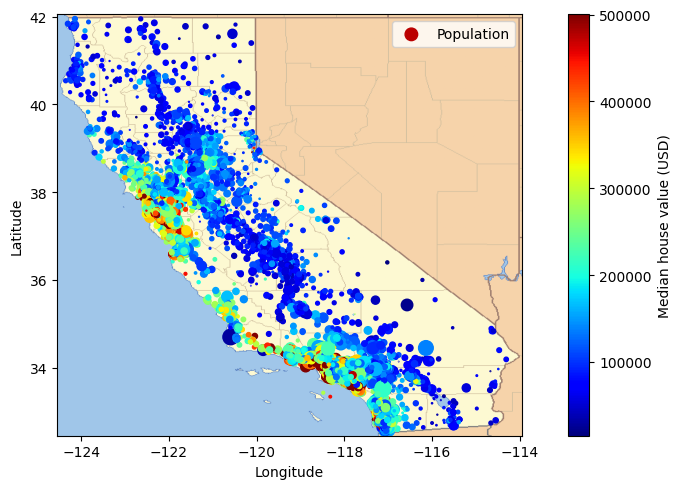

In [6]:
housing_train = strat_train_set.copy()
housing_train.info()

housing_train.plot(kind="scatter", x="longitude", y="latitude", alpha=0.1)

housing_train.plot(kind="scatter",x="longitude",y="latitude",alpha=0.4,s=housing_train["population"]/100,label="population", figsize=FIGSIZE, c="median_house_value", cmap=plt.get_cmap("jet"),colorbar=True,sharex=False)
plt.legend()

filename="california.png"
if not (IMAGES_PATH / filename).is_file():
  homl3_root="https://github.com/ageron/handson-ml3/raw/main/"
  url = homl3_root + "images/end_to_end_project/" + filename
  print("Downloading", filename)
  urllib.request.urlretrieve(url, IMAGES_PATH / filename)
housing_renamed = housing_train.rename(columns={
    "latitude": "Latitude", "longitude": "Longitude",
    "population": "Population",
    "median_house_value": "Median house value (USD)"})
housing_renamed.plot(
    kind="scatter", x="Longitude", y="Latitude",
    s=housing_renamed["Population"]/100,
    label="Population",
    c="Median house value (USD)",
    cmap="jet",
    colorbar=True,
    legend=True,
    sharex=False,
    figsize=FIGSIZE
)

california_img = plt.imread(IMAGES_PATH / filename)
axis = -124.55, -113.95, 32.45, 42.05
plt.axis(axis)
plt.tight_layout()
plt.imshow(california_img, extent=axis)

### [3-A] Correlation

median_house_value    1.000000
median_income         0.689028
total_rooms           0.131907
housing_median_age    0.108183
households            0.061195
total_bedrooms        0.045625
population           -0.027948
longitude            -0.044437
latitude             -0.144475
Name: median_house_value, dtype: float64


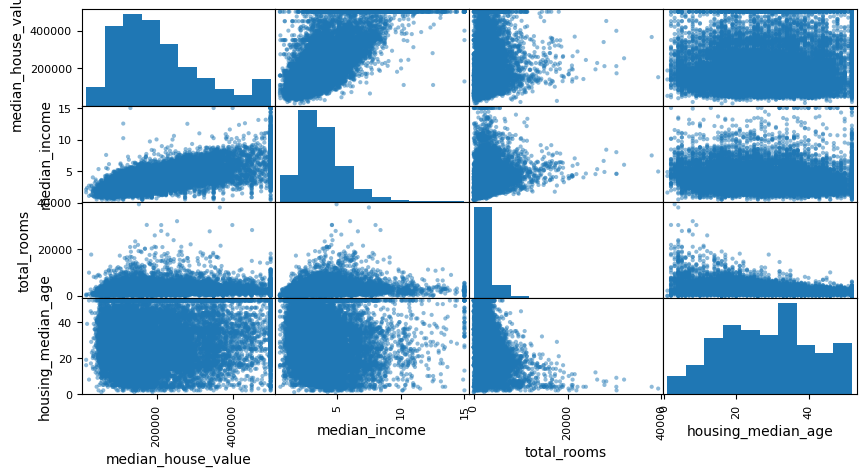

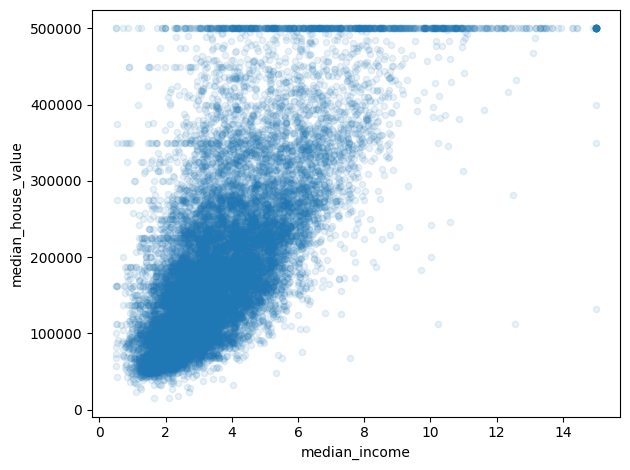

In [7]:
#@title [3-A] Correlation
corr_matrix = housing_train.corr(numeric_only=True)
print(corr_matrix["median_house_value"].sort_values(ascending=False))

'''
Interpretation:

1. Median_house_value is correlated to the median_income the most

2. it is also highly correlated to the total_rooms
'''

from pandas.plotting import scatter_matrix
attributes = ["median_house_value","median_income",
              "total_rooms", "housing_median_age"]
scatter_matrix(housing_train[attributes],figsize=FIGSIZE)
housing_train.plot(kind="scatter", x="median_income",y="median_house_value",alpha=0.1)
plt.tight_layout()

### [3-B] Derived Variable

In [8]:
#@title [3-B] Derived Variable

# EDA 전용 복사본에서만 파생변수를 만든다. (housing_train, 학습 데이터에는 추가하지 않음)
# 실제 학습용 파생변수는 [7] Pipeline의 Adder가 생성한다.
housing_eda = housing_train.copy()
housing_eda["rooms_per_household"] = housing_eda["total_rooms"]/housing_eda["households"]
housing_eda["bedrooms_per_room"] = housing_eda["total_bedrooms"]/housing_eda["total_rooms"]
housing_eda["population_per_household"] = housing_eda["population"]/housing_eda["households"]

corr_matrix_eda = housing_eda.corr(numeric_only=True)
print(corr_matrix_eda["median_house_value"].sort_values(ascending=False))

median_house_value          1.000000
median_income               0.689028
rooms_per_household         0.145564
total_rooms                 0.131907
housing_median_age          0.108183
households                  0.061195
total_bedrooms              0.045625
population                 -0.027948
population_per_household   -0.032359
longitude                  -0.044437
latitude                   -0.144475
bedrooms_per_room          -0.253357
Name: median_house_value, dtype: float64


## [4] Missing Value

### [4-0] Divide Input Data and Label / Check NA

In [9]:
#@title [4-0] Divide Input Data and Label

# 학습 파이프라인(imputer / outlier detection / encoder)은 train set 기준으로만 만든다.
# strat_test_set은 최종 평가 전까지 그대로 보존한다.
# X, y는 strat_train_set에서 직접 만든다. (EDA용 파생변수가 섞이지 않도록 housing_eda 사용 X)
# income_cat은 층화추출 전용 컬럼이므로 X에서 제거한다.
X_train = strat_train_set.drop(["median_house_value", "income_cat"], axis=1)
y_train = strat_train_set["median_house_value"].copy()

X_train.info()

X_train.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 15678 to 4687
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16512 non-null  float64
 1   latitude            16512 non-null  float64
 2   housing_median_age  16512 non-null  float64
 3   total_rooms         16512 non-null  float64
 4   total_bedrooms      16354 non-null  float64
 5   population          16512 non-null  float64
 6   households          16512 non-null  float64
 7   median_income       16512 non-null  float64
 8   ocean_proximity     16512 non-null  object 
dtypes: float64(8), object(1)
memory usage: 1.3+ MB


,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,158
population,0
households,0
median_income,0
ocean_proximity,0


In [10]:
#@title [4-0] Check NA

null_rows_idx = X_train.isnull().any(axis=1)
X_train.loc[null_rows_idx].head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
7763,-118.10,33.91,36.0,726.0,NaN,490.0,130.0,3.6389,<1H OCEAN
19150,-122.70,38.35,14.0,2313.0,NaN,954.0,397.0,3.7813,<1H OCEAN
13933,-117.31,34.25,29.0,4610.0,NaN,1569.0,592.0,2.7663,INLAND
4767,-118.37,34.03,37.0,1236.0,NaN,966.0,292.0,3.0694,<1H OCEAN
4852,-118.31,34.03,47.0,1315.0,NaN,785.0,245.0,1.2300,<1H OCEAN


### [4-A] Drop Rows

In [11]:
# [4-A ~ 4-C Option 1~3]은 비교용 데모이며 Pipeline에는 Option 3(median 대체)만 SimpleImputer로 반영된다.

#Option 1

housing_option1 = X_train.copy()
housing_option1.dropna(subset=["total_bedrooms"],
                       inplace=True)
housing_option1.loc[null_rows_idx].head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity


### [4-B] Drop Columns

In [12]:
#Option 2
housing_option2 = X_train.copy()
housing_option2.drop("total_bedrooms", axis=1, inplace=True)

housing_option2.loc[null_rows_idx].head()

,longitude,latitude,housing_median_age,total_rooms,population,households,median_income,ocean_proximity
7763,-118.10,33.91,36.0,726.0,490.0,130.0,3.6389,<1H OCEAN
19150,-122.70,38.35,14.0,2313.0,954.0,397.0,3.7813,<1H OCEAN
13933,-117.31,34.25,29.0,4610.0,1569.0,592.0,2.7663,INLAND
4767,-118.37,34.03,37.0,1236.0,966.0,292.0,3.0694,<1H OCEAN
4852,-118.31,34.03,47.0,1315.0,785.0,245.0,1.2300,<1H OCEAN


### [4-C] Imputation

In [13]:
#Option 3
housing_option3 = X_train.copy()
median = X_train["total_bedrooms"].median()
housing_option3["total_bedrooms"] = housing_option3["total_bedrooms"].fillna(median)

housing_option3.loc[null_rows_idx].head()

from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")

housing_num = X_train.select_dtypes(include=[np.number])
num_attribs = housing_num.columns.tolist()   # 숫자형 8개 컬럼 (Adder, ColumnTransformer에서 사용)
imputer.fit(housing_num)
imputer.statistics_

housing_num.median().values

housing_num_imputed = imputer.transform(housing_num)

housing_tr = pd.DataFrame(housing_num_imputed, columns=housing_num.columns,
                          index=housing_num.index)

housing_tr.loc[null_rows_idx].head()

imputer.strategy

'median'

## [5] Drop Outliers

In [14]:
#@title [5] Drop Outliers

from sklearn.ensemble import IsolationForest
from sklearn.pipeline import Pipeline

# 이상치 제거는 행을 삭제하므로 Pipeline(변환기 체인) 밖에서, train에만 적용한다. (test는 그대로 둔다)
# IsolationForest는 결측치를 처리하지 못하므로 SimpleImputer와 묶은 탐지용 Pipeline을 따로 만든다.
outlier_detector = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("iforest", IsolationForest(random_state=RANDOM_STATE)),
])
outlier_pred = outlier_detector.fit_predict(X_train[num_attribs])
outlier_pred

outliers = X_train[outlier_pred == -1]
outliers

# X와 y에 같은 mask를 적용해서 행이 어긋나지 않도록 한다.
keep_mask = outlier_pred == 1
X_train_clean = X_train[keep_mask]
y_train_clean = y_train[keep_mask]

# User Defined Convertor

---

In [15]:
from sklearn.base import BaseEstimator, TransformerMixin

# Add Derived Variables to Dataset

room_ix, bedroom_ix, population_ix, households_ix = [
    num_attribs.index(col) for col in ["total_rooms", "total_bedrooms", "population", "households"]
]

class Adder(BaseEstimator, TransformerMixin):
  def fit(self, X, y=None):
    return self
  def transform(self, X):
    rooms_per_household = X[:,room_ix] / X[:,households_ix]
    population_per_household = X[:,population_ix] / X[:, households_ix]
    bedrooms_per_room = X[:,bedroom_ix] / X[:,room_ix]
    return np.c_[X, rooms_per_household, population_per_household, bedrooms_per_room]

adder = Adder()
housing_extra_attr = adder.transform(housing_tr[keep_mask].to_numpy())

housing_extra_df = pd.DataFrame(
    housing_extra_attr,
    columns=num_attribs + ["rooms_per_household", "population_per_household", "bedrooms_per_room"],
    index=X_train_clean.index
)
housing_extra_df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,rooms_per_household,population_per_household,bedrooms_per_room
15678,-122.43,37.80,52.0,1976.0,726.0,1045.0,669.0,3.6893,2.953662,1.562033,0.367409
5952,-117.85,34.12,30.0,4367.0,1033.0,2524.0,954.0,3.0448,4.577568,2.645702,0.236547
8214,-118.19,33.78,29.0,1170.0,369.0,1398.0,373.0,2.2543,3.136729,3.747989,0.315385
10876,-117.88,33.73,32.0,1947.0,355.0,1786.0,332.0,4.5726,5.864458,5.379518,0.182332
7009,-118.07,33.97,36.0,1887.0,370.0,1006.0,329.0,3.1554,5.735562,3.057751,0.196078


## [6] Categorical Variable

In [16]:
#@title [6] Categorical Variable

housing_cat = X_train_clean[["ocean_proximity"]]
housing_cat.head(10)

# Ordinal Encoder
from sklearn.preprocessing import OrdinalEncoder

ordinal_encoder = OrdinalEncoder()
housing_cat_encoded = ordinal_encoder.fit_transform(housing_cat)
housing_cat_encoded[:10]

# One-Hot Encoder
from sklearn.preprocessing import OneHotEncoder

cat_encoder = OneHotEncoder()
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)
housing_cat_1hot.toarray()

cat_encoder = OneHotEncoder(sparse_output=False)
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)
housing_cat_1hot

cat_encoder.categories_

df_test = pd.DataFrame({"ocean_proximity" : ["INLAND",
                                             "NEAR BAY"]})
pd.get_dummies(df_test)

,ocean_proximity_INLAND,ocean_proximity_NEAR BAY
0,True,False
1,False,True


## [7] Pipeline

Pipeline 안 : SimpleImputer / Adder / StandardScaler (숫자형), OneHotEncoder (범주형)

Pipeline 밖 : 분할, EDA, 이상치 제거 (앞 단계에서 이미 처리)

In [17]:
#@title [7] Pipeline

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

cat_attribs = ["ocean_proximity"]

# 숫자형 : 결측치 대체 -> 파생변수 추가 -> 표준화

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("adder", Adder()),
    ("std_scaler", StandardScaler())
])

preprocessing = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_attribs),
])

# train : fit + transform (이상치가 제거된 X_train_clean 사용)
housing_prepared = preprocessing.fit_transform(X_train_clean)
housing_prepared.shape

# test : 이상치 제거 없이, fit 없이 transform만 수행 (모델 평가는 최종 단계에서)
X_test = strat_test_set.drop(["median_house_value", "income_cat"], axis=1)
y_test = strat_test_set["median_house_value"].copy()
X_test_prepared = preprocessing.transform(X_test)
X_test_prepared.shape

(4128, 16)

# Model Learning

In [18]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(housing_prepared, y_train_clean)

LinearRegression()

In [19]:
some_data = housing_raw.iloc[:5]
some_labels = housing_raw[LABEL]
some_data_prepared = preprocessing.transform(some_data)

print(lin_reg.predict(some_data_prepared))

[424498.50580288 463270.91774742 386205.42441209 328194.41711397
 250713.36958716]


In [20]:
some_data_prepared

array([[-1.40801105,  1.13247042,  0.9405669 , -1.25785837, -1.50093811,
        -1.45525004, -1.4894529 ,  2.74421548,  0.69916083, -0.45680217,
        -1.1707325 ,  0.        ,  0.        ,  0.        ,  1.        ,
         0.        ],
       [-1.40282448,  1.12276125, -0.72263315,  4.57015483,  2.94184362,
         1.83593167,  3.45540648,  2.72987575,  0.3838582 , -0.98442316,
        -1.01111706,  0.        ,  0.        ,  0.        ,  1.        ,
         0.        ],
       [-1.41319763,  1.11790666,  1.85532693, -0.7077629 , -1.22354846,
        -1.1797976 , -1.24025544,  2.10085591,  1.25031753, -0.16476184,
        -1.46679053,  0.        ,  0.        ,  0.        ,  1.        ,
         0.        ],
       [-1.41838421,  1.11790666,  1.85532693, -0.88862905, -1.01891675,
        -1.08164788, -1.035034  ,  1.12822493,  0.20600758, -0.46581104,
        -0.51415582,  0.        ,  0.        ,  0.        ,  1.        ,
         0.        ],
       [-1.41838421,  1.11790666,  1

# Evaluation

In [21]:
#@title MSE

from sklearn.metrics import mean_squared_error

housing_predictions = lin_reg.predict(housing_prepared)
lin_mse = mean_squared_error(y_train_clean, housing_predictions)
lin_rmse = np.sqrt(lin_mse)
print(lin_rmse)

63767.86103121419


In [22]:
y_train_clean.mean()

np.float64(203941.54438241452)